# Simulador OHLC
En este notebook nos proponemos exponer diferentes metodologías de simulación para ampliar las simulaciones de montecarlo realizadas anteriormente. En concreto, a partir de las simulaciones anteriores que generan un precio para cada instante de tiempo, en este caso simularemos precios OHLC del activo en cuestión para cada instante de tiempo.

Para esto proponemos esencialmente tres metodologías distintas:

1. Generar precios a incrementos de tiempo menores (sub-pasos) y después agregarlos.
2. Modelado de volatilidad relativa.
3. Uso de puentes Brownianos

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import datos
import SimulacionMonteCarlo

## Visualización de datos
Primeramente desarrollamos métodos para la visualización de datos OHLC. La clase OHLC de la libreria datos es una clase derivada de pd.DataFrame, con algunas funcionalidades añadidas como por ejemplo la creación de gráficos OHLC. Esta clase debe usarse únicamente antes de acceder a dichas funcionalidades, ya que no podemos usarla en general para tratar con DataFrames: las operaciones entre DataFrames devuelven un DataFrame, no un objeto OHLC.

In [3]:
to_drop = ['volume', 'change', 'changePercent', 'vwap']
data = datos.download_stock_data("^GSPC").drop(to_drop, axis=1)

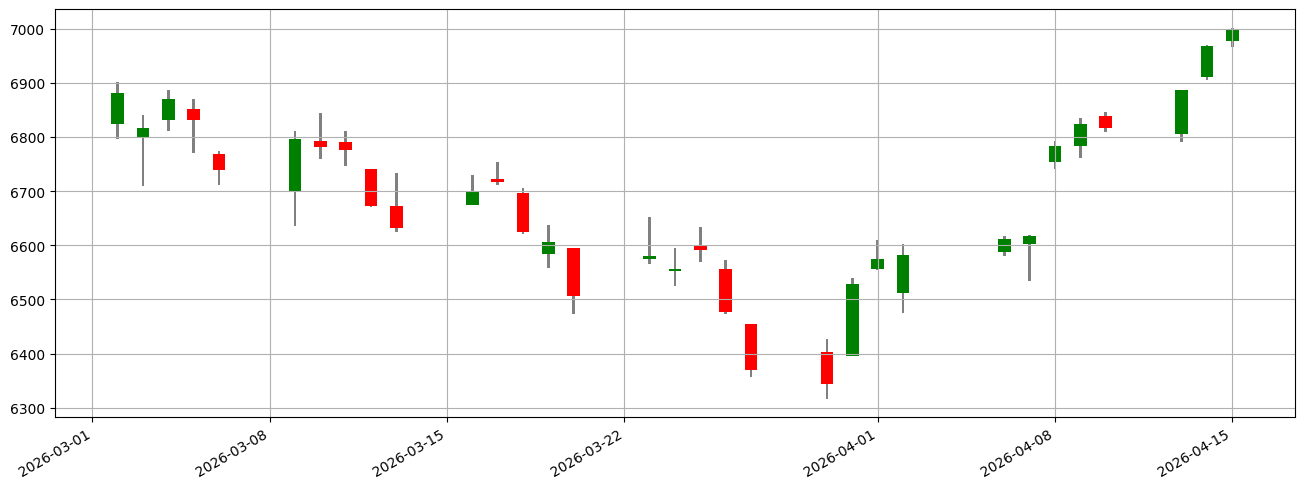

In [4]:
import datos
import importlib
importlib.reload(datos)

tsla_ohlc = datos.OHLC(data[data.index > pd.to_datetime("03-01-2026")])
tsla_ohlc.plot()

## Agregación de subpasos
En este apartado crearemos una serie de datos al minuto a partir de datos diarios. Después agregaremos los datos para crear el gráfico OHLC. 

In [5]:
gbm = SimulacionMonteCarlo.GBM()
gbm.ajustar_parametros(data['close'])

/home/jordi/Documents/educacio/master_unir/practicas/codigo/SimulacionMonteCarlo.py:127: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  new_params = {'T': ts.shape[0], 'N': ts.shape[0], 'Deltat':1., 'S0':ts[0], 'M':M}
/home/jordi/Documents/educacio/master_unir/practicas/codigo/SimulacionMonteCarlo.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  -(ts[k]-ts[k-1]*(1+var_mu*new_params['Deltat']))**2/
/home/jordi/Documents/educacio/master_unir/practicas/codigo/SimulacionMonteCarlo.py:132: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treat

Ajuste de parámetros realizado correctamente.


In [6]:
gbm.mostrar_parametros()

===== Parámetros del modelo =====
T:		1255
N:		1255
Deltat:		1.0
S0:		4185.47
M:		1
mu:		0.0004666965783961334
sigma:		0.010665646516636748


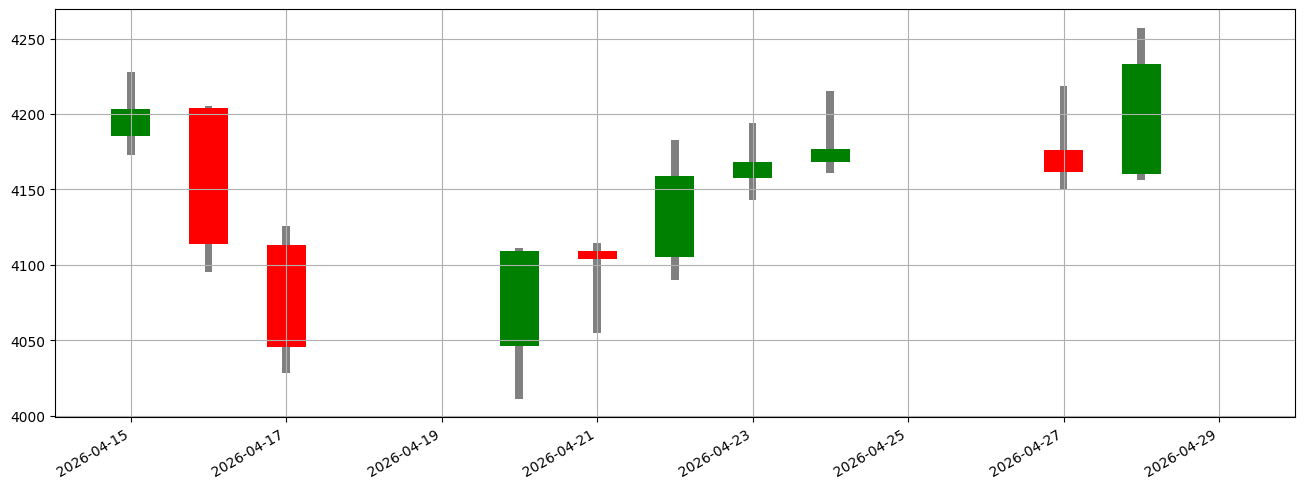

In [7]:
import datos 
importlib.reload(datos)
importlib.reload(SimulacionMonteCarlo)
from datetime import timedelta

gbm.cambiar_escala_temporal(N=10*24*60, Deltat=1/(24*60))
valores = gbm.simular().reshape(-1)
fechas = np.array(datos.next_k_bdates(k=10*24*60+1, start=data.index[-1], delta=timedelta(minutes=1)))
df = pd.DataFrame({'valores': valores})
df.index = fechas
df.index.names = ['fechas']
ohlc = datos.OHLC().desde_simulacion(df)
ohlc.plot()

## Modelado de volatilidad relativa
Tomaremos como precio de cierre el precio del día, el precio de apertura el precio de cierre del día anterior. Para simular el high/low, cogeremos el máximo/mínimo y le sumaremos/restaremos el valor absoluto de una variable normal con media cero y desviación estándar inferior a la de la serie. Nosotros tomaremos como desviación estándar la de la serie dividida por la raíz del número de días de la serie.

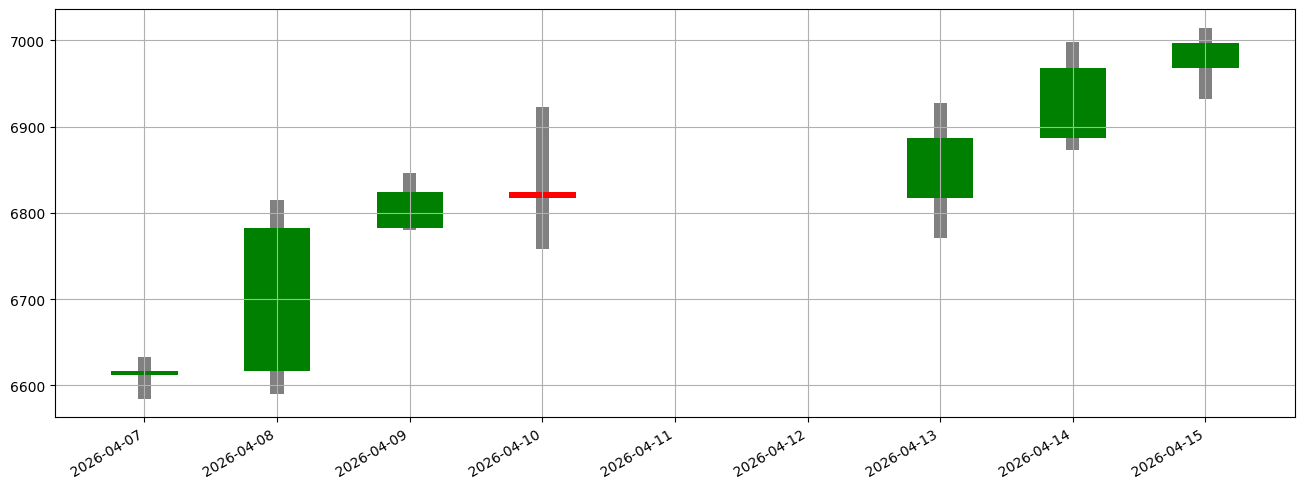

In [8]:
importlib.reload(datos)
ohlc = datos.OHLC().desde_volatilidad_relativa(data['close'].iloc[-11:])
ohlc.plot()

Hemos implementado una pequeña mejora: no usar una volatilidad constane para la variable normal generada, sino una desviación estandar rolling para que la volatilidad del high/low se adapte a las condiciones actuales de mercado.

## Interpolación con puentes brownianos


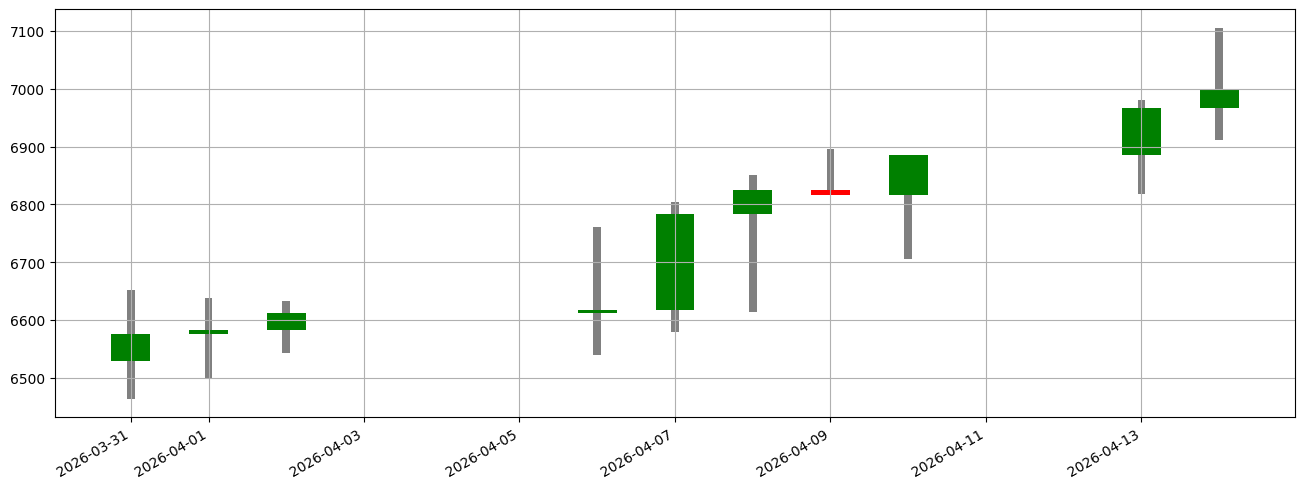

In [9]:
importlib.reload(datos)
ohlc = datos.OHLC().desde_interpolacion_puentes_brownianos(data['close'].iloc[-11:])
ohlc.plot()

Observamos comportamientos extraños en los días festivos, produciendo saltos más allá de lo que se genera en la simulación subyacente. 

En lo que sigue indagamos sobre esto. Este es un gráfico de los valores del S&P500 entre el 25-03-2026 y el 09-04-2026 en naranja, y los valores interpolados en azul. Seguidamente mostramos la agregación OHLC de los datos simulados.

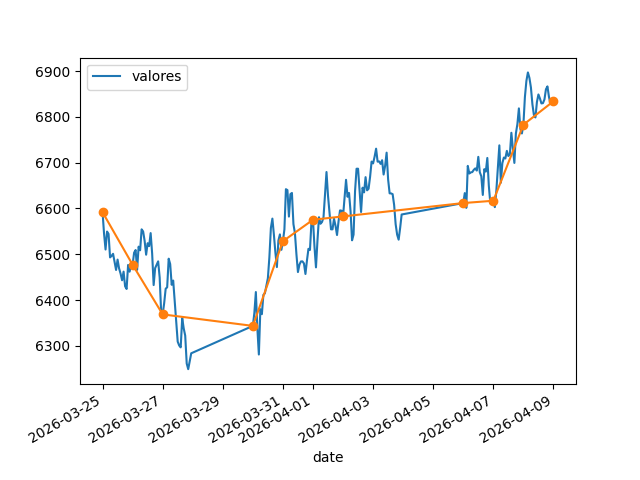
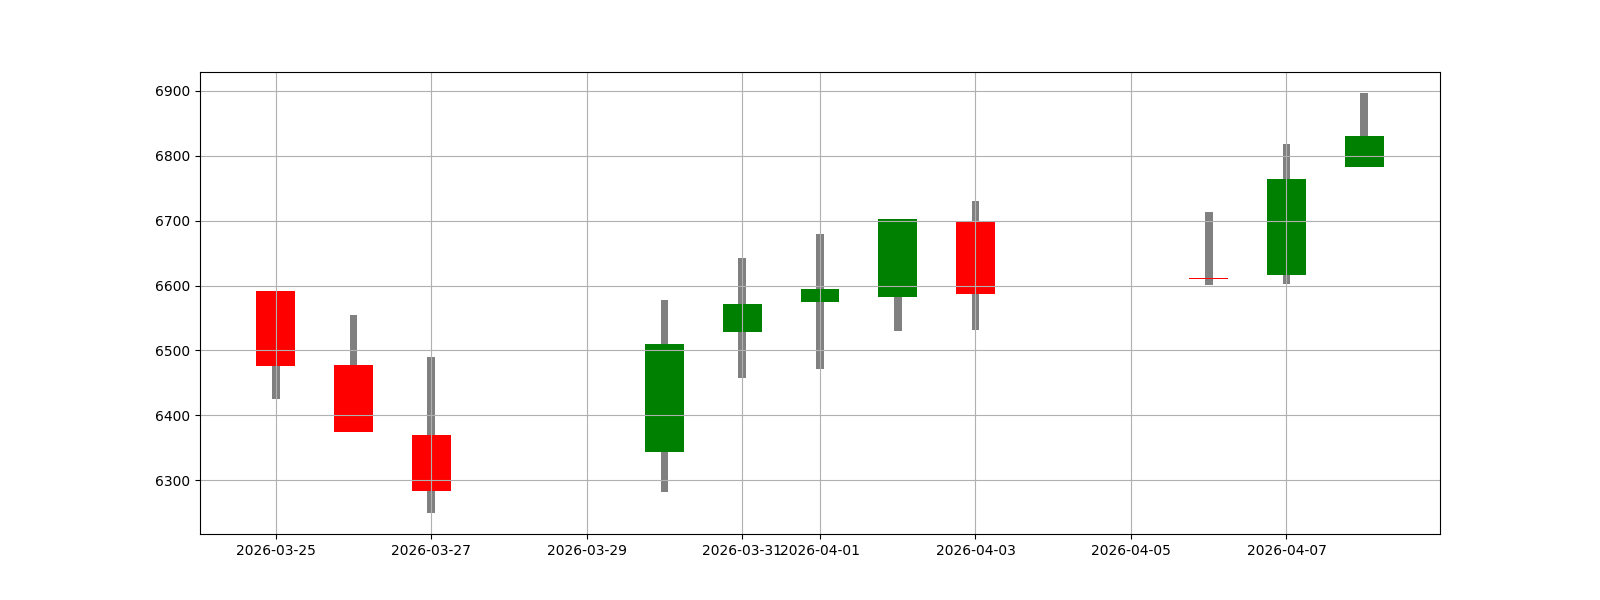

### Problema
Observamos que los saltos desmesurados en los candles antes y después de los fines de semana se deben a que los puentes brownianos se cortan antes de llegar al valor deseado. 


### Solución
La primera solución que proponemos es la de no generar datos en los días festivos. Supongamos que estamos en un fin de semana habitual. Entonces consideraremos el precio de cierre del viernes como el precio de apertura del lunes, pero simularemos un puente browniano solamente entre el precio de apertura del viernes, situado a las 00:00 del viernes, y el precio de apertura del lunes situado a última hora del viernes (la posición temporal exacta depende del número de subdivisiones temporales en las que dividamos el día). Es decir, estamos suponiendo que no hay actividad los días festivos.

<Axes: xlabel='date'>

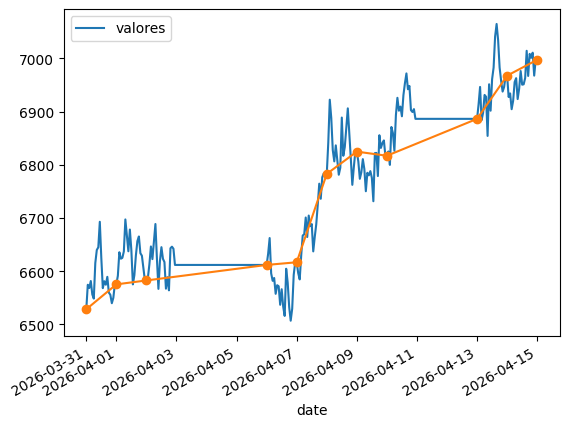

In [10]:
importlib.reload(datos)
interpolacion = datos.OHLC().desde_interpolacion_puentes_brownianos(data['close'].iloc[-11:],
                                                                   retorna_interpolacion=True)
fig, ax = plt.subplots(1,1)
interpolacion.plot(ax=ax)
data['close'].iloc[-11:].plot(ax=ax, marker='o')


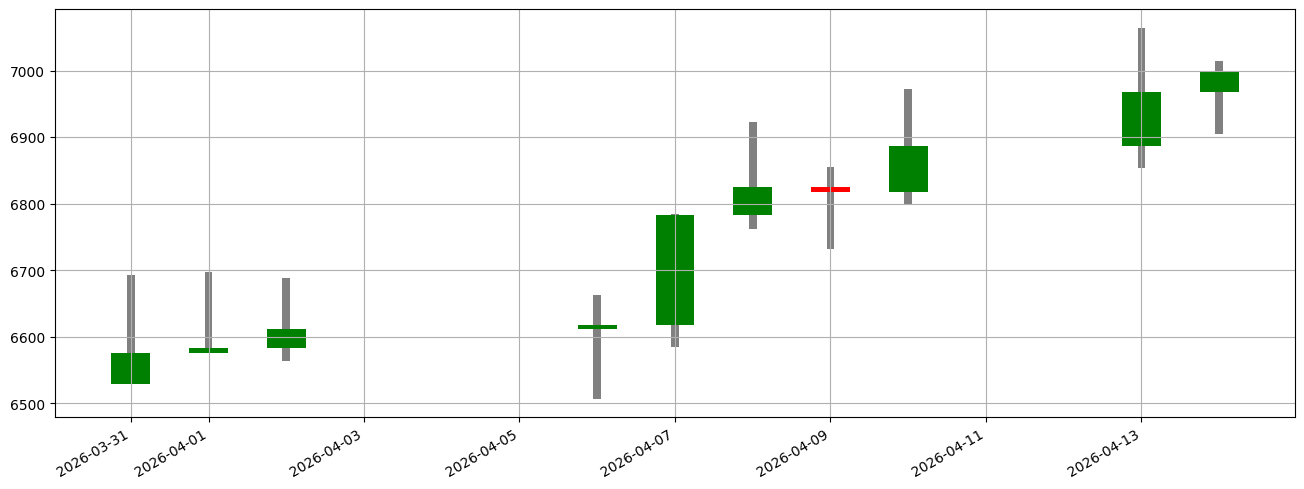

In [11]:
datos.OHLC().desde_simulacion(interpolacion).plot()

# Simulaciones para diferentes tipos de activo
En esta sección consideraremos tres activos diferentes, debido a sus diferentes propiedades en cuanto a volatilidad y saltos en el precio. Los activos que consideraremos son el oro, el eurodólar, el S&P500 y el bono alemán a 10 años.

In [50]:
importlib.reload(datos)

dd = datos.StockDataDownloader()


# futuros sobre el oro, no oro directamente, XAUUSD no está disponible
xau = dd.download_from_any_source("GOLD.US")
eurusd = dd.download_from_any_source("EURUSD")
sp500 = dd.download_from_any_source("^GSPC")
btcusd = dd.download_from_any_source("BTCUSD")
# No encontramos datos para el bono alemán a 10a.
# de10y = dd.download_from_any_source("TMBMKDE-10Y")

Datos de GOLD.US descargados de eodhd.
Datos de EURUSD descargados de fmp.
Datos de ^GSPC descargados de fmp.
Datos de BTCUSD descargados de fmp.


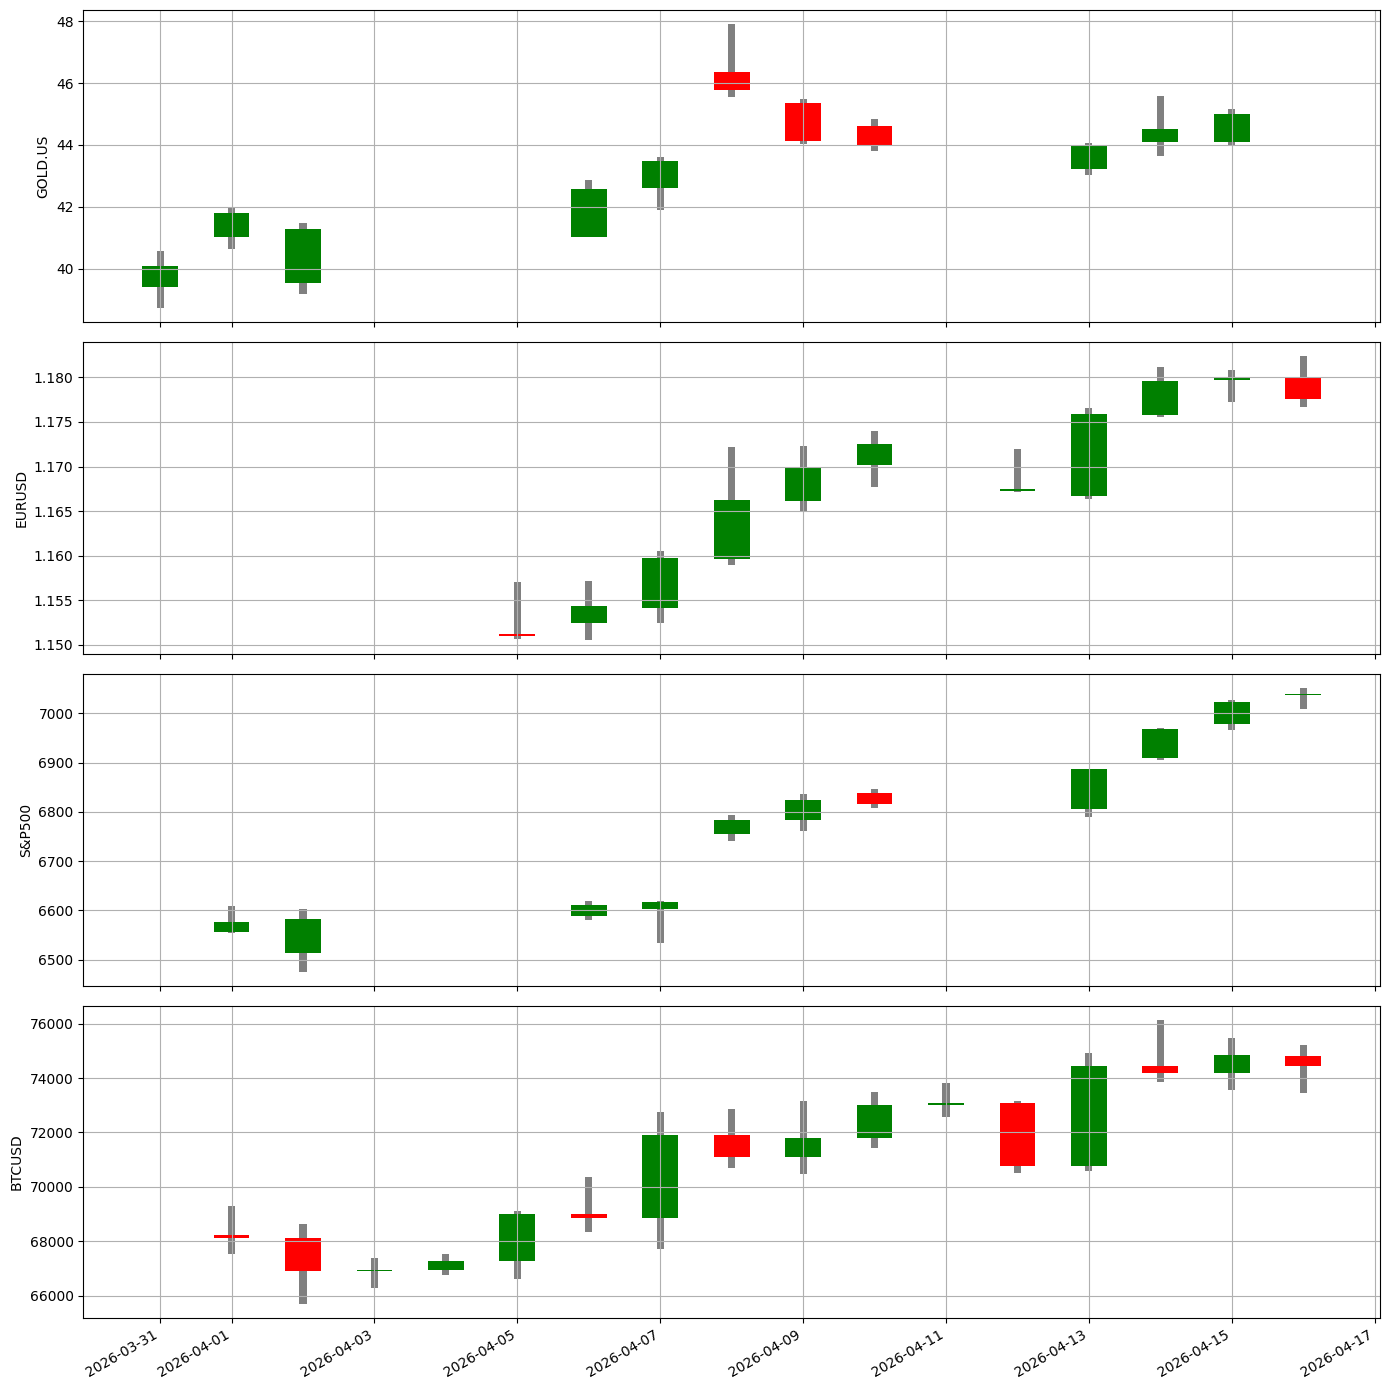

In [51]:
importlib.reload(datos)

fig, axes = plt.subplots(4, 1, figsize = (14,14), sharex=True)
datos.OHLC(xau.iloc[-11:]).plot(ax=axes[0])
axes[0].set_ylabel('GOLD.US')
datos.OHLC(eurusd.iloc[-11:]).plot(ax=axes[1])
axes[1].set_ylabel('EURUSD')
datos.OHLC(sp500.iloc[-11:]).plot(ax=axes[2])
axes[2].set_ylabel('S&P500')
datos.OHLC(btcusd.iloc[-16:]).plot(ax=axes[3])
axes[3].set_ylabel('BTCUSD')
fig.tight_layout()

## Comentarios
En este apartado señalamos algunas de las características observadas en los datos, para comparar con las características de nuestras simulaciones.

1. Nuestro modelo no produce saltos. Es decir, el precio de cierre de un día es el precio de apertura del día siguiente. Como podemos observar en los tres gráficos anteriores, esto no ocurre siempre, ya que podemos observar notables diferencias entre los precios de cierre y los siguientes de apertura.
2. La magnitud de las variables que configuran cada vela son realistas.
3. Hay activos, como el bitcoin, que no cierran ningún día del año, es decir, no hay consideración de día festivo.


Con esto, nos quedan dos cambios por realizar: generar saltos interdía. Los saltos entre día se pueden generar añadiendolos directamente o mediante la simulación de precios en las hora en las que el mercado está cerrado.